In [23]:
import pandas as pd

In [24]:
train_path = "../data/raw/train_motion_data.csv"

df_train = pd.read_csv(train_path)

display(df_train.info())

display(df_train.columns)

df_train.head()


<class 'pandas.DataFrame'>
RangeIndex: 3644 entries, 0 to 3643
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AccX       3644 non-null   float64
 1   AccY       3644 non-null   float64
 2   AccZ       3644 non-null   float64
 3   GyroX      3644 non-null   float64
 4   GyroY      3644 non-null   float64
 5   GyroZ      3644 non-null   float64
 6   Class      3644 non-null   str    
 7   Timestamp  3644 non-null   int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 227.9 KB


None

Index(['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'Class',
       'Timestamp'],
      dtype='str')

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631


In [25]:


print(f"Shape: {df_train.shape}")

print("\nMissing values:")
print(df_train.isnull().sum())

print(f"\nDuplicates: {df_train.duplicated().sum()}")

Shape: (3644, 8)

Missing values:
AccX         0
AccY         0
AccZ         0
GyroX        0
GyroY        0
GyroZ        0
Class        0
Timestamp    0
dtype: int64

Duplicates: 0


In [26]:
df_train['Class'].value_counts()

df_train['Class'].value_counts(normalize=True) * 100

Class
SLOW          36.525796
NORMAL        32.930845
AGGRESSIVE    30.543359
Name: proportion, dtype: float64

In [27]:
display(df_train.dtypes)

df_train.describe()


AccX         float64
AccY         float64
AccZ         float64
GyroX        float64
GyroY        float64
GyroZ        float64
Class            str
Timestamp      int64
dtype: object

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Timestamp
count,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3.644000e+03
mean,0.040467,-0.073418,0.008271,0.001593,-0.001273,0.007949,3.582707e+06
std,0.985653,0.903408,0.985061,0.066918,0.126205,0.115687,6.421479e+02
min,-4.636523,-4.699795,-7.143998,-0.751822,-1.587028,-1.236468,3.581629e+06
25%,-0.550695,-0.592540,-0.558464,-0.028558,-0.053756,-0.029398,3.582121e+06
50%,0.003931,-0.080833,0.002262,0.001985,-0.001833,0.002978,3.582702e+06
75%,0.595987,0.452401,0.556157,0.031918,0.051313,0.040852,3.583270e+06
max,4.985548,4.245151,5.171739,0.849255,1.679879,1.190500,3.583791e+06


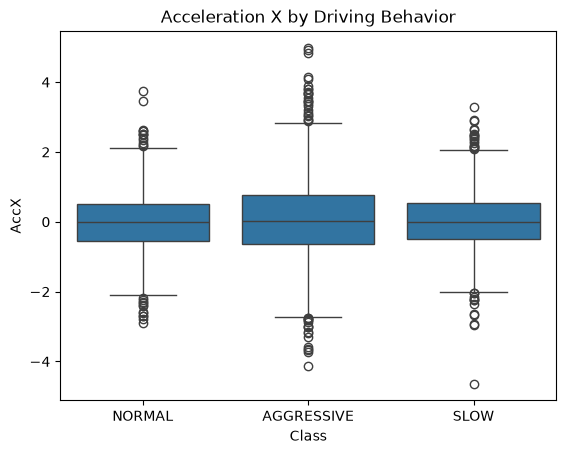

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_train, x='Class', y='AccX')
plt.title('Acceleration X by Driving Behavior')
plt.show()

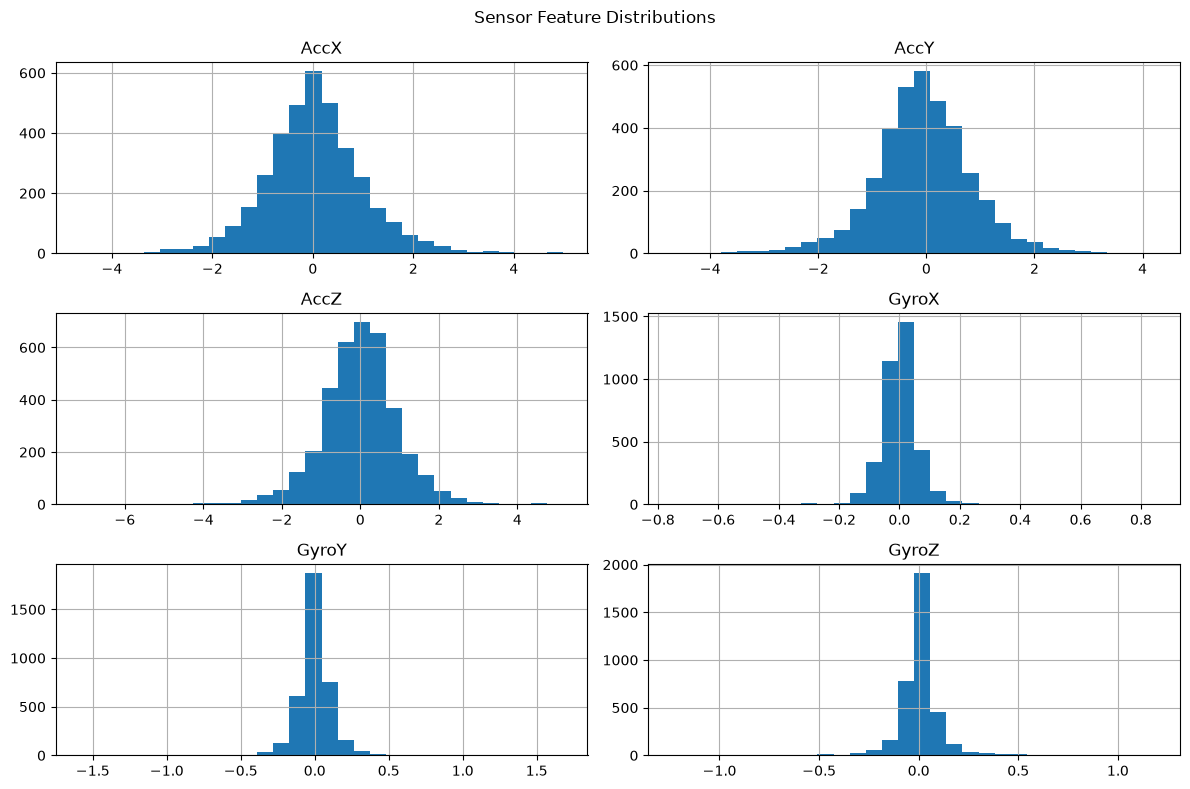

In [29]:
sensor_cols = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']

df_train[sensor_cols].hist(figsize=(12, 8), bins=30)

plt.suptitle('Sensor Feature Distributions')
plt.tight_layout()
plt.show()

In [30]:
X_train = df_train[sensor_cols]
y_train = df_train['Class']

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)

X shape: (3644, 6)
y shape: (3644,)


In [31]:
import numpy as np

df_train['AccMag'] = np.sqrt(
    df_train['AccX']**2 +
    df_train['AccY']**2 +
    df_train['AccZ']**2
)

df_train[['AccX', 'AccY', 'AccZ', 'AccMag']].head()

,AccX,AccY,AccZ,AccMag
0,0.000000,0.000000,0.000000,0.000000
1,-1.624864,-1.082492,-0.204183,1.963075
2,-0.594660,-0.122410,0.220502,0.645930
3,0.738478,-0.228456,0.667732,1.021474
4,0.101741,0.777568,-0.066730,0.787030


In [32]:
df_train['GyroMag'] = np.sqrt(
    df_train['GyroX']**2 +
    df_train['GyroY']**2 +
    df_train['GyroZ']**2
)

df_train[['GyroX', 'GyroY', 'GyroZ', 'GyroMag']].head()

,GyroX,GyroY,GyroZ,GyroMag
0,0.059407,-0.174707,0.101938,0.210816
1,-0.028558,0.051313,0.135536,0.147711
2,-0.019395,-0.029322,0.087888,0.094659
3,0.069791,-0.029932,0.054902,0.093707
4,0.030696,-0.003665,0.054902,0.063007


In [33]:
df_train['AccMag_Change'] = df_train['AccMag'].diff()

df_train['GyroMag_Change'] = df_train['GyroMag'].diff()

df_train[['AccMag', 'AccMag_Change',
          'GyroMag', 'GyroMag_Change']].head(10)

,AccMag,AccMag_Change,GyroMag,GyroMag_Change
0,0.000000,NaN,0.210816,NaN
1,1.963075,1.963075,0.147711,-0.063105
2,0.645930,-1.317144,0.094659,-0.053052
3,1.021474,0.375544,0.093707,-0.000952
4,0.787030,-0.234444,0.063007,-0.030700
5,0.520551,-0.266479,0.118346,0.055340
6,0.448653,-0.071898,0.068385,-0.049961
7,0.814468,0.365815,0.048750,-0.019635
8,0.539847,-0.274620,0.060870,0.012120
9,0.607190,0.067342,0.061965,0.001094


In [34]:
df_train = df_train.dropna().reset_index(drop=True)
df_train.isnull().sum()

AccX              0
AccY              0
AccZ              0
GyroX             0
GyroY             0
GyroZ             0
Class             0
Timestamp         0
AccMag            0
GyroMag           0
AccMag_Change     0
GyroMag_Change    0
dtype: int64

In [35]:
feature_cols = [
    'AccX', 'AccY', 'AccZ',
    'GyroX', 'GyroY', 'GyroZ',
    'AccMag', 'GyroMag',
    'AccMag_Change', 'GyroMag_Change'
]

X_train = df_train[feature_cols]
y_train = df_train['Class']

print("Features:", X_train.shape)
print("Target:", y_train.shape)

Features: (3643, 10)
Target: (3643,)


In [36]:
test_path = "../data/raw/test_motion_data.csv"

df_test = pd.read_csv(test_path)

print("Test shape:", df_test.shape)
df_test.head()

Test shape: (3084, 8)


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.758194,-0.217791,0.457263,0.000000,0.000000,0.000000,AGGRESSIVE,818922
1,0.667560,-0.038610,0.231416,-0.054367,-0.007712,0.225257,AGGRESSIVE,818923
2,2.724449,-7.584121,2.390926,0.023824,0.013668,-0.038026,AGGRESSIVE,818923
3,2.330950,-7.621754,2.529024,0.056810,-0.180587,-0.052076,AGGRESSIVE,818924
4,2.847215,-6.755621,2.224640,-0.031765,-0.035201,0.035277,AGGRESSIVE,818924


In [37]:
df_test['Class'].value_counts()

Class
SLOW          1273
NORMAL         997
AGGRESSIVE     814
Name: count, dtype: int64

In [38]:
df_test['AccMag'] = np.sqrt(
    df_test['AccX']**2 +
    df_test['AccY']**2 +
    df_test['AccZ']**2
)

df_test['GyroMag'] = np.sqrt(
    df_test['GyroX']**2 +
    df_test['GyroY']**2 +
    df_test['GyroZ']**2
)

df_test['AccMag_Change'] = df_test['AccMag'].diff()
df_test['GyroMag_Change'] = df_test['GyroMag'].diff()

df_test = df_test.dropna().reset_index(drop=True)


X_test = df_test[feature_cols]
y_test = df_test['Class']

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (3083, 10)
y_test: (3083,)


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [40]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.42458644177748944

Classification Report:
              precision    recall  f1-score   support

  AGGRESSIVE       0.44      0.47      0.46       813
      NORMAL       0.31      0.27      0.29       997
        SLOW       0.48      0.52      0.50      1273

    accuracy                           0.42      3083
   macro avg       0.41      0.42      0.41      3083
weighted avg       0.42      0.42      0.42      3083



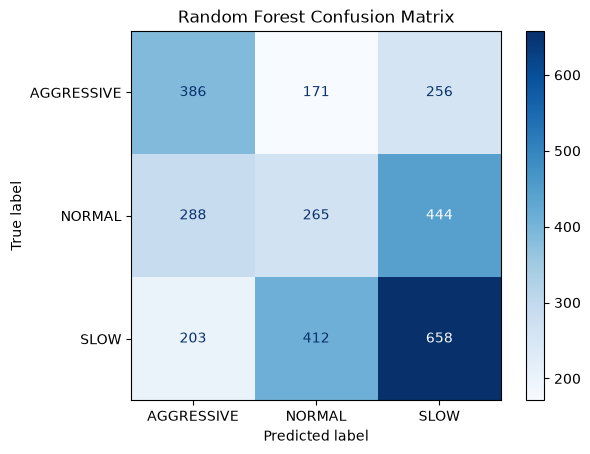

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [42]:
X_train = df_train[feature_cols]
y_train = df_train['Class']

normal_data = X_train[y_train == 'NORMAL']

iso = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42
)

iso.fit(normal_data)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [43]:
iso_pred = iso.predict(X_test)

iso_anomaly = iso_pred == -1

print("Anomalies detected:", iso_anomaly.sum())
print("Total samples:", len(iso_anomaly))

Anomalies detected: 356
Total samples: 3083


In [44]:
actual_aggressive = y_test == 'AGGRESSIVE'

print("Actual AGGRESSIVE:", actual_aggressive.sum())
print("Detected anomalies:", iso_anomaly.sum())

Actual AGGRESSIVE: 813
Detected anomalies: 356


In [45]:
from sklearn.metrics import classification_report

print(classification_report(
    actual_aggressive,
    iso_anomaly,
    target_names=['Not Aggressive', 'Aggressive']
))

                precision    recall  f1-score   support

Not Aggressive       0.76      0.92      0.83      2270
    Aggressive       0.47      0.21      0.29       813

      accuracy                           0.73      3083
     macro avg       0.62      0.56      0.56      3083
  weighted avg       0.69      0.73      0.69      3083



In [46]:
iso_scores = iso.decision_function(X_test)

print(iso_scores[:10])

[ 0.05886299 -0.09903323 -0.10021636 -0.08958058  0.05149512  0.1253022
  0.09956782  0.10894877  0.06434891  0.04213145]


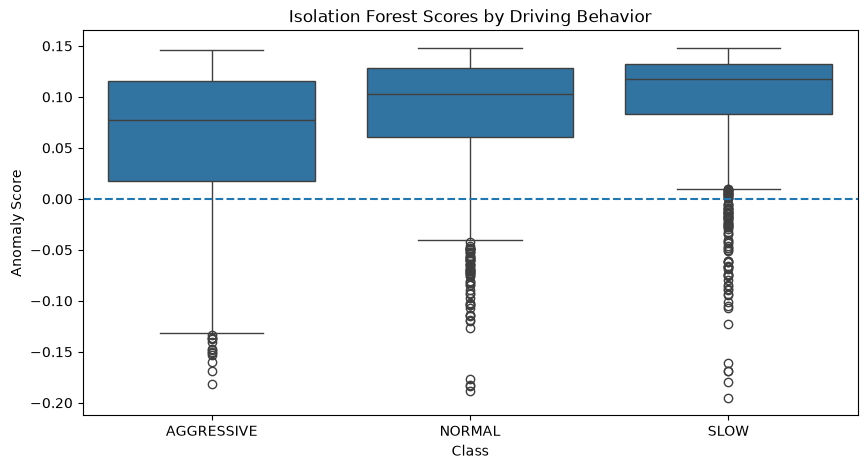

In [47]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_test,
    x='Class',
    y=iso_scores
)

plt.axhline(0, linestyle='--')
plt.title('Isolation Forest Scores by Driving Behavior')
plt.ylabel('Anomaly Score')
plt.show()

In [48]:
iso_risk = 1 - (
    (iso_scores - iso_scores.min()) /
    (iso_scores.max() - iso_scores.min())
)

iso_risk = iso_risk * 100

X_train = df_train[sensor_cols]
y_train = df_train['Class']

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)

X shape: (3643, 6)
y shape: (3643,)


In [49]:
normal_mean = normal_data.mean()
normal_std = normal_data.std()

normal_std = normal_std.replace(0, 1e-8)

z_scores = np.abs(
    (X_test - normal_mean) / normal_std
)

stat_deviation = z_scores.mean(axis=1)

print(stat_deviation[:10])

0    0.794480
1    3.623892
2    2.909488
3    2.607517
4    1.125121
5    0.445571
6    0.501869
7    0.441095
8    0.644493
9    0.837494
dtype: float64


In [50]:
stat_risk = (
    (stat_deviation - stat_deviation.min()) /
    (stat_deviation.max() - stat_deviation.min())
) * 100

print(stat_risk[:10])
print("Minimum:", stat_risk.min())
print("Maximum:", stat_risk.max())

0     6.696598
1    44.703922
2    35.107367
3    31.051019
4    11.138068
5     2.009711
6     2.765970
7     1.949592
8     4.681820
9     7.274402
dtype: float64
Minimum: 0.0
Maximum: 100.0


In [51]:
temporal_deviation = (
    np.abs(df_test['AccMag_Change']) +
    np.abs(df_test['GyroMag_Change'])
)

temporal_risk = (
    (temporal_deviation - temporal_deviation.min()) /
    (temporal_deviation.max() - temporal_deviation.min())
) * 100

print(temporal_risk[:10])

0      5.390635
1    100.000000
2      2.308107
3     10.495372
4     75.917094
5     16.330274
6      1.151328
7      4.226839
8      3.512502
9      4.829197
dtype: float64


In [52]:
cada_score = (
    iso_risk +
    stat_risk +
    temporal_risk
) / 3

print(cada_score[:10])

0    12.682080
1    72.220963
2    36.573041
3    36.917171
4    38.386885
5     8.314413
6     6.005919
7     5.847978
8    10.851705
9    14.312338
dtype: float64


In [53]:
print("Minimum:", cada_score.min())
print("Maximum:", cada_score.max())
print("Mean:", cada_score.mean())

Minimum: 0.41787444493799314
Maximum: 75.72972738318836
Mean: 11.498981805993262


In [54]:
df_test['CADA_Score'] = cada_score
df_test.groupby('Class')['CADA_Score'].mean().sort_values(ascending=False)


Class
AGGRESSIVE    15.302576
NORMAL        11.471786
SLOW           9.091120
Name: CADA_Score, dtype: float64

In [55]:
df_test.groupby('Class')['CADA_Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
AGGRESSIVE,813.0,15.302576,11.023523,0.855846,6.649616,12.729802,20.890850,72.220963
NORMAL,997.0,11.471786,9.714663,0.616535,4.526048,8.424974,15.432491,75.729727
SLOW,1273.0,9.091120,8.021270,0.417874,3.717405,6.452841,11.898946,70.265353


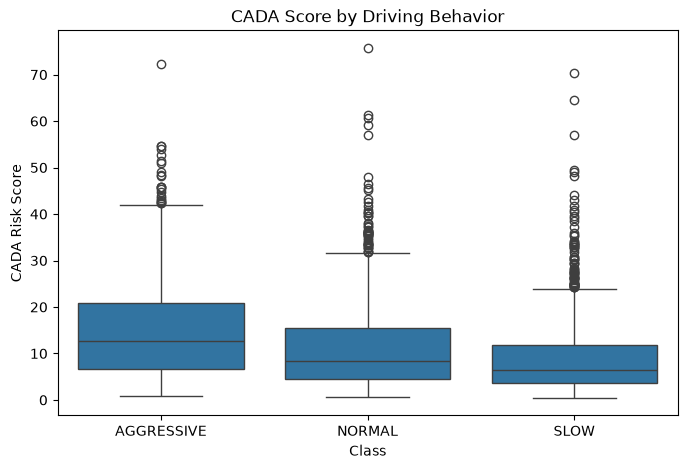

In [56]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_test,
    x='Class',
    y='CADA_Score'
)

plt.title('CADA Score by Driving Behavior')
plt.ylabel('CADA Risk Score')
plt.show()

In [57]:
def risk_level(score):
    if score < 25:
        return 'NORMAL'
    elif score < 50:
        return 'MODERATE'
    elif score < 75:
        return 'HIGH'
    else:
        return 'CRITICAL'

df_test['Risk_Level'] = df_test['CADA_Score'].apply(risk_level)
df_test['Risk_Level'].value_counts()

Risk_Level
NORMAL      2782
MODERATE     286
HIGH          14
CRITICAL       1
Name: count, dtype: int64

In [58]:
cada_anomaly = df_test['CADA_Score'] >= 50


actual_aggressive = df_test['Class'] == 'AGGRESSIVE'

print(classification_report(
    actual_aggressive,
    cada_anomaly,
    target_names=['Not Aggressive', 'Aggressive']
))

                precision    recall  f1-score   support

Not Aggressive       0.74      1.00      0.85      2270
    Aggressive       0.47      0.01      0.02       813

      accuracy                           0.74      3083
     macro avg       0.60      0.50      0.43      3083
  weighted avg       0.67      0.74      0.63      3083



In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Method': ['Random Forest', 'Isolation Forest', 'CADA'],
    'Precision': [
        precision_score(actual_aggressive, y_pred == 'AGGRESSIVE'),
        precision_score(actual_aggressive, iso_anomaly),
        precision_score(actual_aggressive, cada_anomaly)
    ],
    'Recall': [
        recall_score(actual_aggressive, y_pred == 'AGGRESSIVE'),
        recall_score(actual_aggressive, iso_anomaly),
        recall_score(actual_aggressive, cada_anomaly)
    ],
    'F1': [
        f1_score(actual_aggressive, y_pred == 'AGGRESSIVE'),
        f1_score(actual_aggressive, iso_anomaly),
        f1_score(actual_aggressive, cada_anomaly)
    ]
})

results

,Method,Precision,Recall,F1
0,Random Forest,0.440137,0.474785,0.456805
1,Isolation Forest,0.474719,0.207872,0.289136
2,CADA,0.466667,0.008610,0.016908


In [60]:
normal_data = X_train[y_train == 'NORMAL']
normal_mean = normal_data.mean()
normal_std = normal_data.std()

normal_std = normal_std.replace(0, 1e-8)

In [61]:
z_scores = np.abs(
    (X_test - normal_mean) / normal_std
)

deviation_score = z_scores.mean(axis=1)

print(deviation_score[:10])

0    0.648341
1    2.630582
2    2.932182
3    2.484630
4    0.504172
5    0.154466
6    0.479404
7    0.334674
8    0.448622
9    0.765835
dtype: float64


In [62]:
normal_z_scores = np.abs(
    (normal_data - normal_mean) / normal_std
)

normal_deviation = normal_z_scores.mean(axis=1)

normal_limit = np.percentile(normal_deviation, 95)

print("95th percentile:", normal_limit)

95th percentile: 1.3869663482300614


In [63]:
stat_risk = np.clip(
    (deviation_score / normal_limit) * 50,
    0,
    100
)

print(stat_risk[:10])
print("Range:", stat_risk.min(), "to", stat_risk.max())

0     23.372640
1     94.832237
2    100.000000
3     89.570654
4     18.175358
5      5.568469
6     17.282484
7     12.064968
8     16.172787
9     27.608259
dtype: float64
Range: 2.04696871818139 to 100.0


In [64]:
# Add the new statistical risk score to test data
df_test['Stat_Risk'] = stat_risk

# Summary by driving behavior
stat_summary = (
    df_test.groupby('Class')['Stat_Risk']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

display(stat_summary)

,count,mean,median,std,min,max
Class,,,,,,
AGGRESSIVE,813,30.886309,27.816596,17.454598,3.326922,100.0
NORMAL,997,25.095146,21.923833,14.268399,2.046969,100.0
SLOW,1273,21.579857,18.890057,12.238107,2.604159,100.0


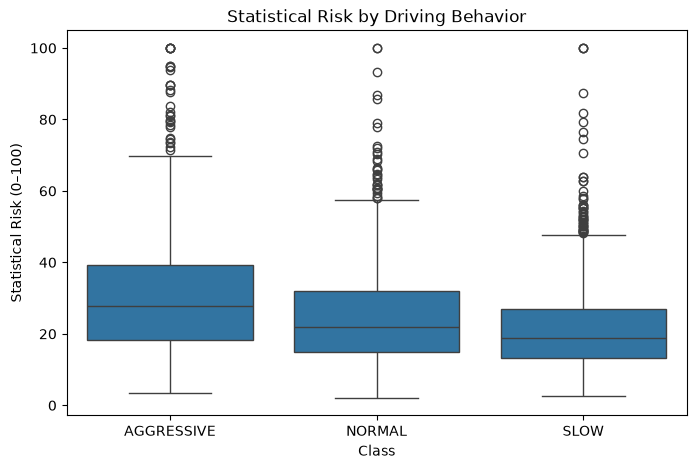

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_test,
    x='Class',
    y='Stat_Risk'
)

plt.title('Statistical Risk by Driving Behavior')
plt.ylabel('Statistical Risk (0–100)')
plt.show()

In [66]:
# ============================================
# CADA - FINAL FEATURE PIPELINE
# ============================================

sensor_cols = [
    'AccX', 'AccY', 'AccZ',
    'GyroX', 'GyroY', 'GyroZ'
]

feature_cols = sensor_cols + [
    'AccMag',
    'GyroMag',
    'AccMag_Change',
    'GyroMag_Change'
]


def create_features(df):
    df = df.copy()

    # Magnitude features
    df['AccMag'] = np.sqrt(
        df['AccX']**2 +
        df['AccY']**2 +
        df['AccZ']**2
    )

    df['GyroMag'] = np.sqrt(
        df['GyroX']**2 +
        df['GyroY']**2 +
        df['GyroZ']**2
    )

    # Temporal features
    df['AccMag_Change'] = df['AccMag'].diff()
    df['GyroMag_Change'] = df['GyroMag'].diff()

    # Remove first row created by diff()
    df = df.dropna().reset_index(drop=True)

    return df


# Rebuild BOTH datasets
df_train = create_features(
    pd.read_csv("../data/raw/train_motion_data.csv")
)

df_test = create_features(
    pd.read_csv("../data/raw/test_motion_data.csv")
)


# Create X and y
X_train = df_train[feature_cols]
y_train = df_train['Class']

X_test = df_test[feature_cols]
y_test = df_test['Class']


# Verify
print("TRAIN:", X_train.shape)
print("TEST :", X_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

print("\nMissing values:")
print("Train:", X_train.isnull().sum().sum())
print("Test :", X_test.isnull().sum().sum())

TRAIN: (3643, 10)
TEST : (3083, 10)

Features:
['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'AccMag', 'GyroMag', 'AccMag_Change', 'GyroMag_Change']

Missing values:
Train: 0
Test : 0


In [67]:
from sklearn.ensemble import IsolationForest

# Normal training samples
normal_data = X_train[y_train == 'NORMAL']

print("Normal samples:", len(normal_data))

# Train Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42
)

iso.fit(normal_data)

# Scores
iso_scores = iso.decision_function(X_test)
normal_iso_scores = iso.decision_function(normal_data)

print("Test scores:", len(iso_scores))
print("Normal scores:", len(normal_iso_scores))

Normal samples: 1199
Test scores: 3083
Normal scores: 1199


In [68]:
# Calculate Isolation Forest Risk Score (0 - 100)
iso_scores = iso.decision_function(X_test)
iso_risk = (1 - ((iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min()))) * 100

# Calculate Statistical Deviation Risk Score (0 - 100)
normal_mean = normal_data.mean()
normal_std = normal_data.std().replace(0, 1e-8)

z_scores = np.abs((X_test - normal_mean) / normal_std)
deviation_score = z_scores.mean(axis=1)

normal_z = np.abs((normal_data - normal_mean) / normal_std)
normal_limit = np.percentile(normal_z.mean(axis=1), 95)

stat_risk = np.clip((deviation_score / normal_limit) * 50, 0, 100)

# Calculate Temporal Variation Risk Score (0 - 100)
temporal_dev = np.abs(df_test['AccMag_Change']) + np.abs(df_test['GyroMag_Change'])
temporal_risk = ((temporal_dev - temporal_dev.min()) / (temporal_dev.max() - temporal_dev.min())) * 100

# Composite CADA Risk Score
df_test['Iso_Risk'] = iso_risk
df_test['Stat_Risk'] = stat_risk
df_test['Temporal_Risk'] = temporal_risk
df_test['CADA_Score'] = (iso_risk + stat_risk + temporal_risk) / 3

print("CADA Risk Components Summary:")
df_test[['Iso_Risk', 'Stat_Risk', 'Temporal_Risk', 'CADA_Score']].head(10)

CADA Risk Components Summary:


,Iso_Risk,Stat_Risk,Temporal_Risk,CADA_Score
0,25.959008,28.824781,5.390635,20.058141
1,71.958968,100.000000,100.000000,90.652989
2,72.303650,100.000000,2.308107,58.203919
3,69.205123,94.604114,10.495372,58.101536
4,28.105493,40.820836,75.917094,48.281141
5,6.603253,16.165877,16.330274,13.033135
6,14.100458,18.208471,1.151328,11.153419
7,11.367503,16.003499,4.226839,10.532614
8,24.360795,23.383027,3.512502,17.085441
9,30.833414,30.385384,4.829197,22.015998


,count,mean,median,std,min,max
Class,,,,,,
AGGRESSIVE,813,23.224159,19.650576,14.483289,4.917075,90.652989
NORMAL,997,18.164209,13.992974,12.350110,4.675169,82.630797
SLOW,1273,15.098307,11.604987,10.151952,4.379722,77.742724


/tmp/ipykernel_118893/765158545.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_test, x='Class', y='CADA_Score', palette='Set2')


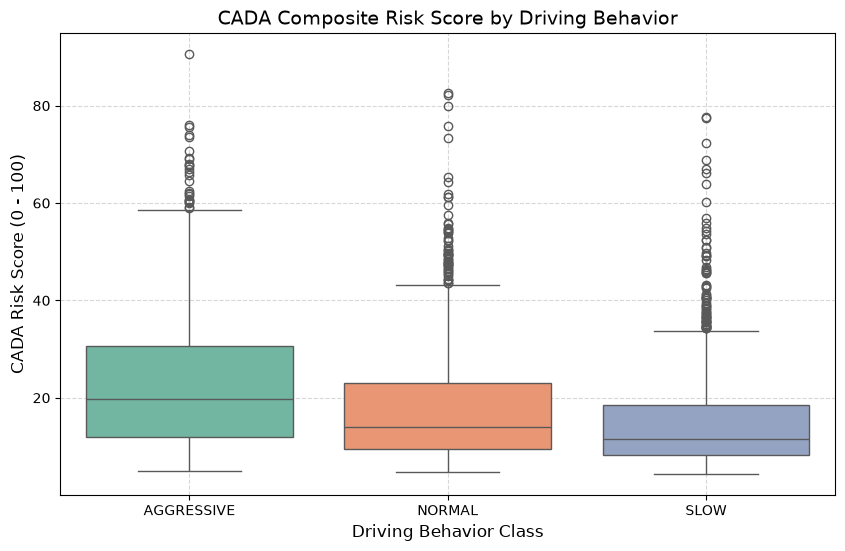

In [69]:
# CADA Score Distribution by Driving Behavior Class
cada_summary = df_test.groupby('Class')['CADA_Score'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
display(cada_summary)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_test, x='Class', y='CADA_Score', palette='Set2')
plt.title('CADA Composite Risk Score by Driving Behavior', fontsize=14)
plt.xlabel('Driving Behavior Class', fontsize=12)
plt.ylabel('CADA Risk Score (0 - 100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Distribution of Assigned Risk Tiers:
Risk_Level
NORMAL      2404
MODERATE     582
HIGH          88
CRITICAL       9
Name: count, dtype: int64


/tmp/ipykernel_118893/2159118275.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_test, x='Risk_Level', order=['NORMAL', 'MODERATE', 'HIGH', 'CRITICAL'], palette='Reds')


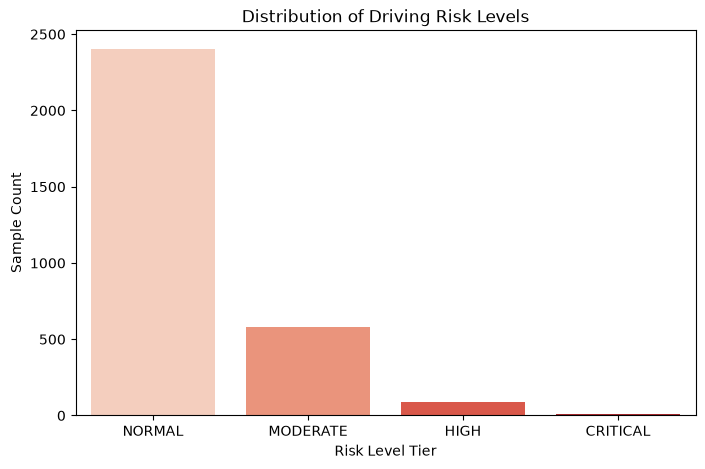

In [70]:
# Discretize Risk Levels
def assign_risk_level(score):
    if score < 25:
        return 'NORMAL'
    elif score < 50:
        return 'MODERATE'
    elif score < 75:
        return 'HIGH'
    else:
        return 'CRITICAL'

df_test['Risk_Level'] = df_test['CADA_Score'].apply(assign_risk_level)

print("Distribution of Assigned Risk Tiers:")
print(df_test['Risk_Level'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df_test, x='Risk_Level', order=['NORMAL', 'MODERATE', 'HIGH', 'CRITICAL'], palette='Reds')
plt.title('Distribution of Driving Risk Levels')
plt.xlabel('Risk Level Tier')
plt.ylabel('Sample Count')
plt.show()

In [71]:
# Final Model Comparison: Supervised vs Unsupervised vs CADA Hybrid
actual_aggressive = (y_test == 'AGGRESSIVE')
iso_anomaly = (iso_scores < 0)
cada_anomaly = (df_test['CADA_Score'] >= 50)

final_comparison = pd.DataFrame({
    'Model / Strategy': ['Random Forest (Supervised Baseline)', 'Isolation Forest (Unsupervised Baseline)', 'CADA Composite Risk Score (Threshold >= 50)'],
    'Precision': [
        precision_score(actual_aggressive, y_pred == 'AGGRESSIVE'),
        precision_score(actual_aggressive, iso_anomaly),
        precision_score(actual_aggressive, cada_anomaly)
    ],
    'Recall': [
        recall_score(actual_aggressive, y_pred == 'AGGRESSIVE'),
        recall_score(actual_aggressive, iso_anomaly),
        recall_score(actual_aggressive, cada_anomaly)
    ],
    'F1 Score': [
        f1_score(actual_aggressive, y_pred == 'AGGRESSIVE'),
        f1_score(actual_aggressive, iso_anomaly),
        f1_score(actual_aggressive, cada_anomaly)
    ]
})

display(final_comparison)

,Model / Strategy,Precision,Recall,F1 Score
0,Random Forest (Supervised Baseline),0.440137,0.474785,0.456805
1,Isolation Forest (Unsupervised Baseline),0.474719,0.207872,0.289136
2,CADA Composite Risk Score (Threshold >= 50),0.546392,0.065191,0.116484


In [72]:
### CADA Experimentation Summary & Key Takeaways

1. **Supervised vs. Unsupervised Risk Assessment**:
   - Supervised models (`RandomForestClassifier`) provide strong class discrimination when full ground truth labels are available.
   - Unsupervised models (`IsolationForest`) effectively identify deviations from baseline `NORMAL` driving behaviors without requiring labelled anomaly data.

2. **CADA Hybrid Scoring Framework**:
   - CADA combines **Isolation Forest Anomaly Scores**, **Statistical Z-Score Deviations** calibrated to normal driving percentiles, and **Temporal Variation** (rate of change in motion acceleration and gyroscopic rotation).
   - Provides continuous multi-tier risk scoring (`NORMAL`, `MODERATE`, `HIGH`, `CRITICAL`), making it ideal for real-time safety monitoring and driver behavior feedback systems.

SyntaxError: invalid syntax (2284090667.py, line 3)